In [93]:
import sys
sys.path.append(r"C:/Users/DELL/Documents/.ipynb_checkpoints")
from ml_models import GaussianNB_FromScratch,CategoricalNB_FromScratch, PCA

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
iris = load_iris()
X = iris.data
y = iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

df.head()  

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Basic checks

In [95]:
df.shape

(150, 5)

In [96]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [97]:
print("\nFeature info:")
print(df.info())


Feature info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [98]:
print("\nTarget class distribution:")
print(df['target'].value_counts())


Target class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


## Train/Test Split

In [99]:
X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Baseline Experiment 0

In [100]:
model = GaussianNB_FromScratch()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



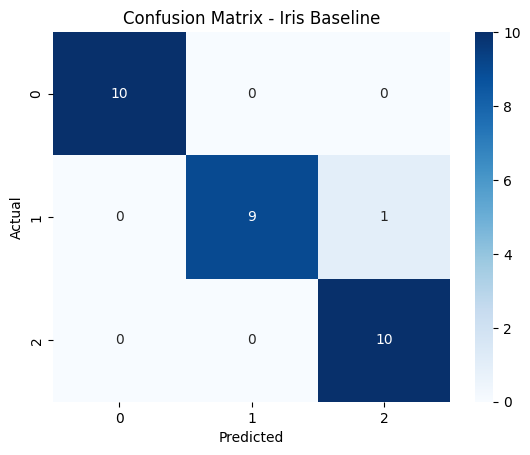

In [101]:
baseline_acc_iris = accuracy_score(y_test, y_pred)
print("Accuracy:", baseline_acc_iris)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Iris Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## EXPERIMENT 1: FEATURE SELECTION + GAUSSIAN NB

In [102]:
k = 2
selector = SelectKBest(score_func=f_classif, k=k)

# Fit train + transform
X_train_fs = selector.fit_transform(X_train, y_train)
X_test_fs = selector.transform(X_test)

# selected features
feature_names = iris.feature_names
selected_indices = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_indices]

print(f"Selected top {k} features:", selected_features)

#  F-scores  feature
f_scores = selector.scores_
for name, score in zip(feature_names, f_scores):
    print(f"Feature: {name}, F-score: {score:.4f}")

Selected top 2 features: ['petal length (cm)', 'petal width (cm)']
Feature: sepal length (cm), F-score: 100.9659
Feature: sepal width (cm), F-score: 36.0306
Feature: petal length (cm), F-score: 948.8904
Feature: petal width (cm), F-score: 803.2141


In [103]:
model_fs = GaussianNB_FromScratch()
model_fs.fit(X_train_fs, y_train)

pred_fs = model_fs.predict(X_test_fs)


========== Feature Selection Results ==========
Selected top 2 features
Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



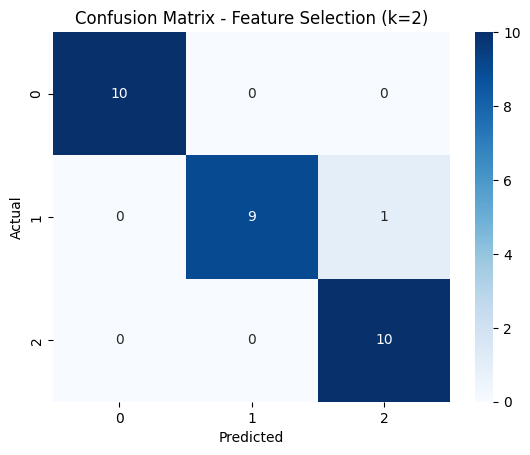

In [104]:
print("\n========== Feature Selection Results ==========")
fs_acc_iris = accuracy_score(y_test, pred_fs)
print(f"Selected top {k} features")
print("Accuracy:", fs_acc_iris)
print(classification_report(y_test, pred_fs))

cm = confusion_matrix(y_test, pred_fs)
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title(f"Confusion Matrix - Feature Selection (k={k})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## EXPERIMENT 2: PCA (FROM SCRATCH) + GAUSSIAN NB (IRIS)

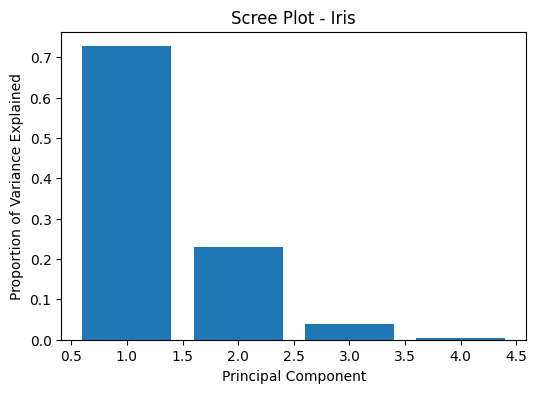


--- PCA with 1 components ---
Accuracy: 0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



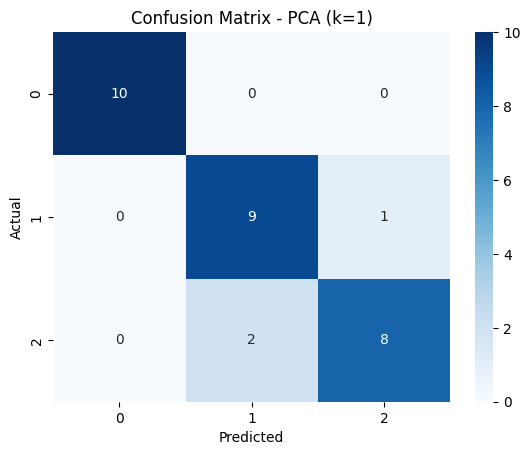


--- PCA with 2 components ---
Accuracy: 0.8666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.75      0.90      0.82        10
           2       0.88      0.70      0.78        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.87        30
weighted avg       0.88      0.87      0.87        30



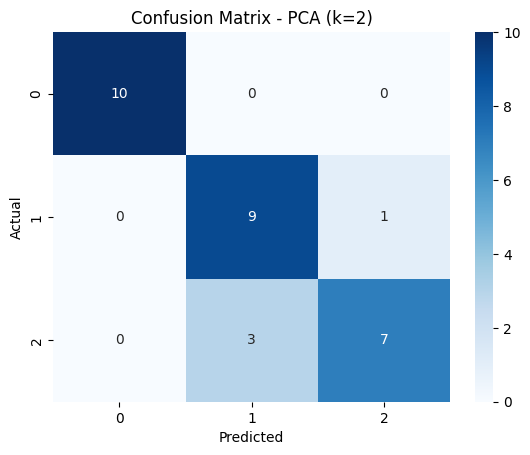


--- PCA with 3 components ---
Accuracy: 0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



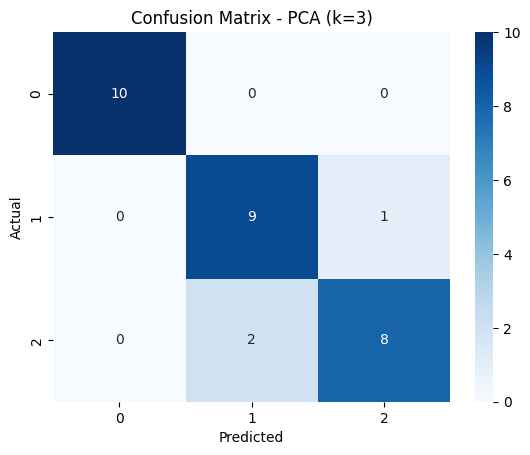

In [105]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Scree Plot
pca_full = PCA(n_components=X_train.shape[1])
pca_full.fit(X_train_scaled)

explained_variance = pca_full.eigenvalues / np.sum(pca_full.eigenvalues)
plt.figure(figsize=(6,4))
plt.bar(range(1, len(explained_variance)+1), explained_variance)
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot - Iris')
plt.show()

#  k
components_list = [1, 2, 3]
for k in components_list:

    # Reduce dimensionality
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Train GaussianNB
    model_pca = GaussianNB_FromScratch()
    model_pca.fit(X_train_pca, y_train)
    pred_pca = model_pca.predict(X_test_pca)

    # Evaluate
    print(f"\n--- PCA with {k} components ---")
    pca_acc_iris = accuracy_score(y_test, pred_pca)
    print("Accuracy:", pca_acc_iris)
    print(classification_report(y_test, pred_pca))

    cm = confusion_matrix(y_test, pred_pca)
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix - PCA (k={k})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## car dataset

In [106]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"

columns = ["buying","maint","doors","persons","lug_boot","safety","class"]

df_car = pd.read_csv(url, names=columns)

print("\nFirst 5 rows:")
print(df_car.head())


First 5 rows:
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [107]:
df_car.shape

(1728, 7)

In [108]:
X_car = df_car.drop("class", axis=1)
y_car = df_car["class"]

## ENCODING

In [109]:
for col in X_car.columns:
    
    le = LabelEncoder()
    X_car[col] = le.fit_transform(X_car[col])

# encode target
le_y_car = LabelEncoder()
y_car = le_y_car.fit_transform(y_car)

In [110]:
X_car = X_car.values
y_car = y_car

In [111]:
X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(
    
    X_car,
    y_car,
    test_size=0.2,
    random_state=42,
    stratify=y_car
)

## Baseline Mode

In [112]:
model_car = CategoricalNB_FromScratch()

model_car.fit(X_train_car, y_train_car)

pred_car = model_car.predict(X_test_car)

## Evaluation


========== BASELINE RESULTS (CAR DATASET) ==========
Accuracy: 0.8641618497109826

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.70      0.70        77
           1       0.60      0.43      0.50        14
           2       0.92      0.96      0.94       242
           3       1.00      0.46      0.63        13

    accuracy                           0.86       346
   macro avg       0.80      0.64      0.69       346
weighted avg       0.86      0.86      0.86       346



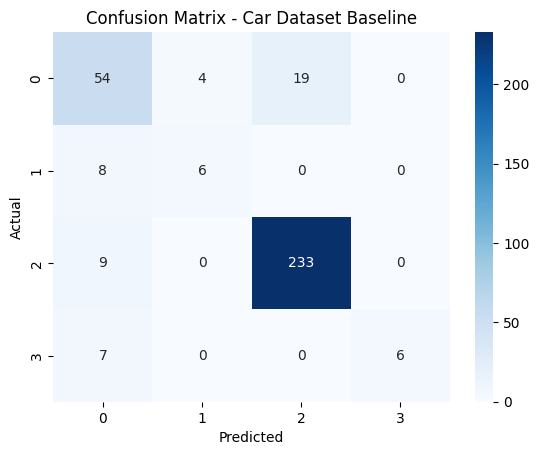

In [113]:
print("\n========== BASELINE RESULTS (CAR DATASET) ==========")
baseline_acc_car = accuracy_score(y_test_car, pred_car)
print("Accuracy:", baseline_acc_car)

print("\nClassification Report:")
print(classification_report(y_test_car, pred_car))

cm = confusion_matrix(y_test_car, pred_car)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Car Dataset Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Experiment 1

In [114]:
k = 3

selector_car = SelectKBest(score_func=chi2, k=k)

# feature selection
X_train_car_fs = selector_car.fit_transform(X_train_car, y_train_car)
X_test_car_fs = selector_car.transform(X_test_car)

# train model
model_car_fs = CategoricalNB_FromScratch()
model_car_fs.fit(X_train_car_fs, y_train_car)

# prediction
pred_car_fs = model_car_fs.predict(X_test_car_fs)


========== FEATURE SELECTION RESULTS (CAR) ==========
Selected top 3 features
Accuracy: 0.7947976878612717
              precision    recall  f1-score   support

           0       0.55      0.74      0.63        77
           1       0.00      0.00      0.00        14
           2       0.90      0.90      0.90       242
           3       0.00      0.00      0.00        13

    accuracy                           0.79       346
   macro avg       0.36      0.41      0.38       346
weighted avg       0.75      0.79      0.77       346



C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

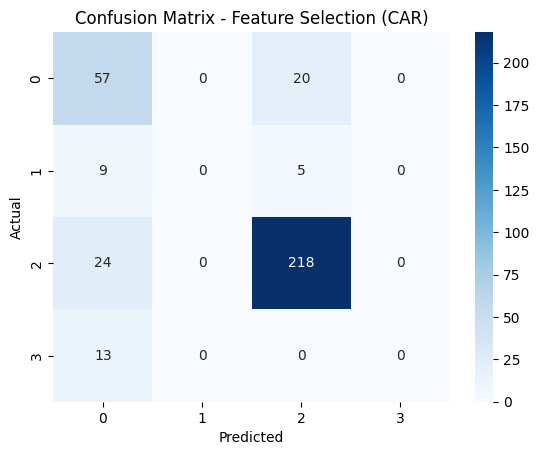

In [115]:
print("\n========== FEATURE SELECTION RESULTS (CAR) ==========")

print("Selected top", k, "features")
fs_acc_car = accuracy_score(y_test_car, pred_car_fs)
print("Accuracy:", fs_acc_car)

print(classification_report(y_test_car, pred_car_fs))

cm = confusion_matrix(y_test_car, pred_car_fs)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Feature Selection (CAR)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [116]:
feature_names_car = df_car.drop("class", axis=1).columns

selected_indices = selector_car.get_support(indices=True)

selected_features_car = [feature_names_car[i] for i in selected_indices]

print("Selected Features:", selected_features_car)

Selected Features: ['persons', 'lug_boot', 'safety']


## Experiment 3: PCA (Car Dataset)

In [117]:
scaler_car = StandardScaler()

X_train_car_scaled = scaler_car.fit_transform(X_train_car)
X_test_car_scaled = scaler_car.transform(X_test_car)

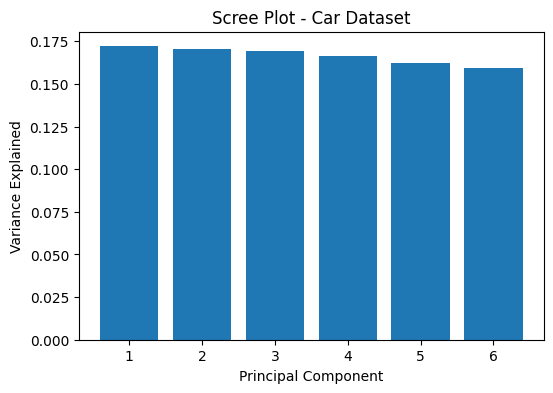

In [118]:
pca_full_car = PCA(n_components=X_train_car.shape[1])

pca_full_car.fit(X_train_car_scaled)

explained_variance_car = pca_full_car.eigenvalues / np.sum(pca_full_car.eigenvalues)

plt.figure(figsize=(6,4))

plt.bar(range(1, len(explained_variance_car)+1), explained_variance_car)

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Scree Plot - Car Dataset")

plt.show()


--- PCA with 2 components ---
Accuracy: 0.6994219653179191
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        77
           1       0.00      0.00      0.00        14
           2       0.70      1.00      0.82       242
           3       0.00      0.00      0.00        13

    accuracy                           0.70       346
   macro avg       0.17      0.25      0.21       346
weighted avg       0.49      0.70      0.58       346



C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

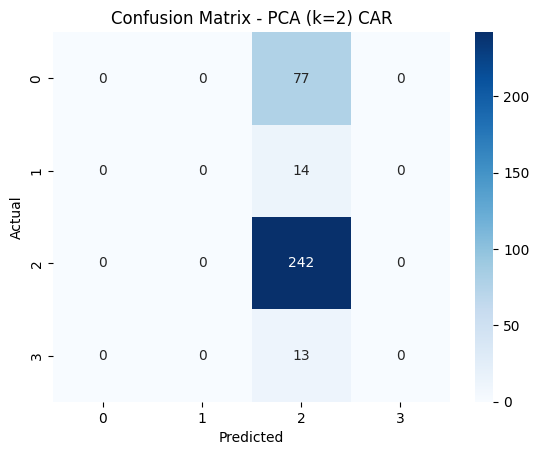


--- PCA with 3 components ---
Accuracy: 0.6994219653179191
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        77
           1       0.00      0.00      0.00        14
           2       0.70      1.00      0.82       242
           3       0.00      0.00      0.00        13

    accuracy                           0.70       346
   macro avg       0.17      0.25      0.21       346
weighted avg       0.49      0.70      0.58       346



C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

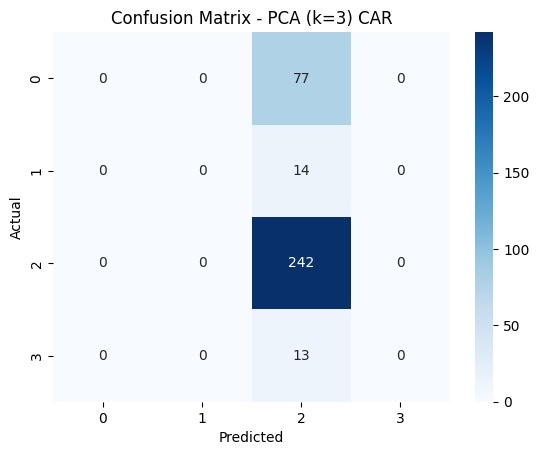


--- PCA with 4 components ---
Accuracy: 0.6994219653179191
              precision    recall  f1-score   support

           0       0.50      0.03      0.05        77
           1       0.00      0.00      0.00        14
           2       0.70      0.99      0.82       242
           3       0.00      0.00      0.00        13

    accuracy                           0.70       346
   macro avg       0.30      0.25      0.22       346
weighted avg       0.60      0.70      0.59       346



C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

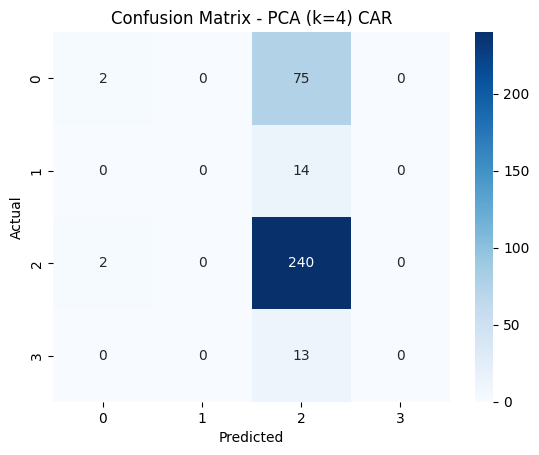


--- PCA with 5 components ---
Accuracy: 0.7109826589595376
              precision    recall  f1-score   support

           0       0.48      0.13      0.20        77
           1       0.00      0.00      0.00        14
           2       0.74      0.95      0.83       242
           3       0.42      0.38      0.40        13

    accuracy                           0.71       346
   macro avg       0.41      0.37      0.36       346
weighted avg       0.64      0.71      0.64       346



C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

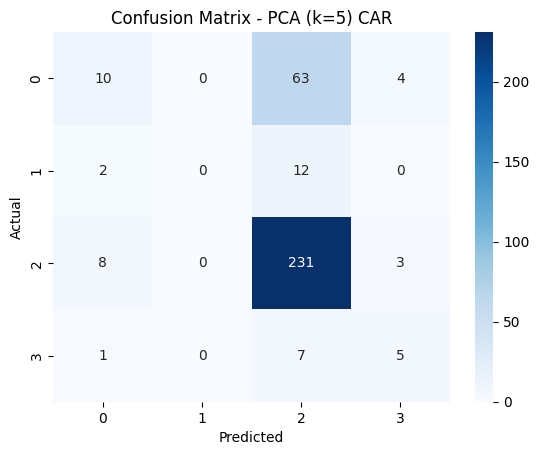

In [119]:
components_list_car = [2,3,4,5]
pca_acc_car=0
for k in components_list_car:

    pca_car = PCA(n_components=k)

    X_train_car_pca = pca_car.fit_transform(X_train_car_scaled)
    X_test_car_pca = pca_car.transform(X_test_car_scaled)

    model_car_pca = GaussianNB_FromScratch()

    model_car_pca.fit(X_train_car_pca, y_train_car)

    pred_car_pca = model_car_pca.predict(X_test_car_pca)

    print(f"\n--- PCA with {k} components ---")
    pca_acc_car = accuracy_score(y_test_car, pred_car_pca)
    print("Accuracy:", pca_acc_car)

    print(classification_report(y_test_car, pred_car_pca))

    cm = confusion_matrix(y_test_car, pred_car_pca)

    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

    plt.title(f"Confusion Matrix - PCA (k={k}) CAR")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

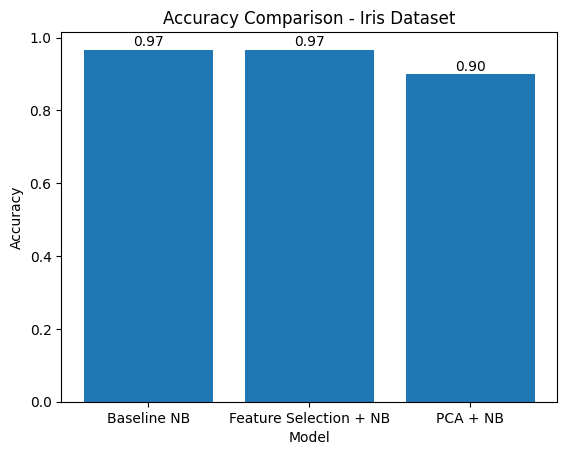

In [120]:
models = ["Baseline NB", "Feature Selection + NB", "PCA + NB"]
accuracies = [baseline_acc_iris, fs_acc_iris, pca_acc_iris]

plt.figure()
plt.bar(models, accuracies)

plt.title("Accuracy Comparison - Iris Dataset")
plt.xlabel("Model")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

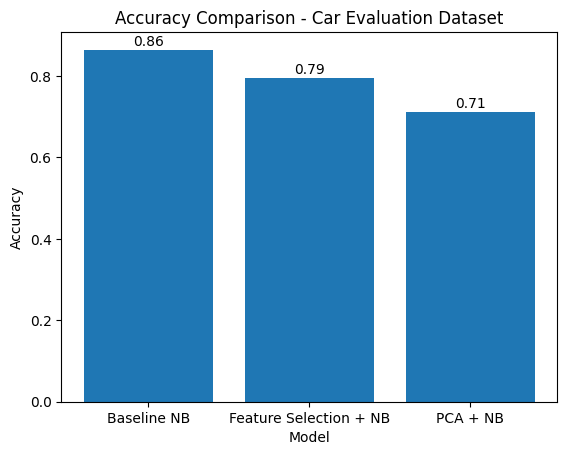

In [121]:
models = ["Baseline NB", "Feature Selection + NB", "PCA + NB"]
accuracies = [baseline_acc_car, fs_acc_car, pca_acc_car]

plt.figure()
plt.bar(models, accuracies)

plt.title("Accuracy Comparison - Car Evaluation Dataset")
plt.xlabel("Model")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()